## Data Visualization

### Setup   

In [62]:
#%pip install scienceplots
%pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 8.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 11.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 17.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [63]:
# libraries
import matplotlib.pyplot as plt ## for basic plotting
import matplotlib as mpl ## for setting default parameters
import pandas as pd ## always
import os ## for handling file paths 1
from pathlib import Path ## for handling file paths 2
import numpy as np ## for numerical operations
import seaborn as sns ## for more advanced plotting
import scienceplots ## for better default plot styles
from sklearn.preprocessing import StandardScaler
import geopandas as gpd

In [64]:
# paths
base_dir = Path("/Users/hannahmaihojgaard/Documents/GitHub/datascience2026")
data_path = Path(base_dir / "data")

### Load in data

In [3]:
# load cleaned dataset
train_df = pd.read_parquet(
    data_path / "taxi_train_2024_2025.parquet"
)

## EDA

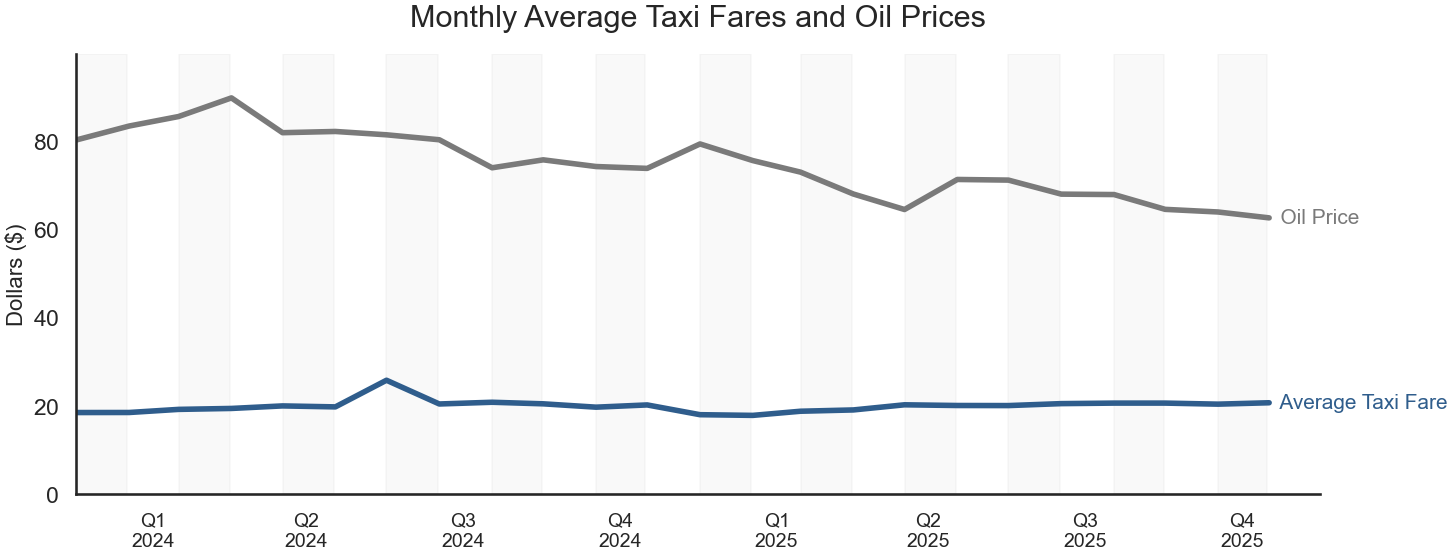

In [27]:
# monthly averages
monthly_plot = train_df.groupby("month_date").agg(
    avg_fare=("fare_amount", "mean"),
    avg_oil_price=("oil_price", "mean")
).reset_index()

sns.set_theme(style="white", context="talk")

fig, ax = plt.subplots(figsize=(15, 6))

# alternating month shading
month_starts = pd.date_range(
    start="2024-01-01",
    end="2025-12-01",
    freq="MS"
)

for i, month_start in enumerate(month_starts):
    if i % 2 == 0:
        ax.axvspan(
            month_start,
            month_start + pd.offsets.MonthEnd(1),
            color="gray",
            alpha=0.045
        )

# lines
ax.plot(
    monthly_plot["month_date"],
    monthly_plot["avg_oil_price"],
    linewidth=4,
    color="#7A7A7A"
)

ax.plot(
    monthly_plot["month_date"],
    monthly_plot["avg_fare"],
    linewidth=4,
    color="#2F5D8C"
)

# direct labels
last_date = monthly_plot["month_date"].iloc[-1]

ax.text(
    last_date,
    monthly_plot["avg_oil_price"].iloc[-1],
    "  Oil Price",
    va="center",
    fontsize=15,
    color="#7A7A7A"
)

ax.text(
    last_date,
    monthly_plot["avg_fare"].iloc[-1],
    "  Average Taxi Fare",
    va="center",
    fontsize=15,
    color="#2F5D8C"
)

# quarter labels
quarter_ticks = [
    pd.Timestamp("2024-02-15"),
    pd.Timestamp("2024-05-15"),
    pd.Timestamp("2024-08-15"),
    pd.Timestamp("2024-11-15"),
    pd.Timestamp("2025-02-15"),
    pd.Timestamp("2025-05-15"),
    pd.Timestamp("2025-08-15"),
    pd.Timestamp("2025-11-15"),
]

quarter_labels = [
    "Q1\n2024", "Q2\n2024", "Q3\n2024", "Q4\n2024",
    "Q1\n2025", "Q2\n2025", "Q3\n2025", "Q4\n2025"
]

ax.set_xticks(quarter_ticks)
ax.set_xticklabels(quarter_labels, fontsize=14)

# labels and limits
ax.set_title("Monthly Average Taxi Fares and Oil Prices", fontsize=22, pad=20)
ax.set_ylabel("Dollars ($)", fontsize=16)
ax.set_xlabel("")

ax.set_xlim(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2025-12-31")
)

ax.set_ylim(
    0,
    max(monthly_plot["avg_fare"].max(), monthly_plot["avg_oil_price"].max()) + 10
)

# clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

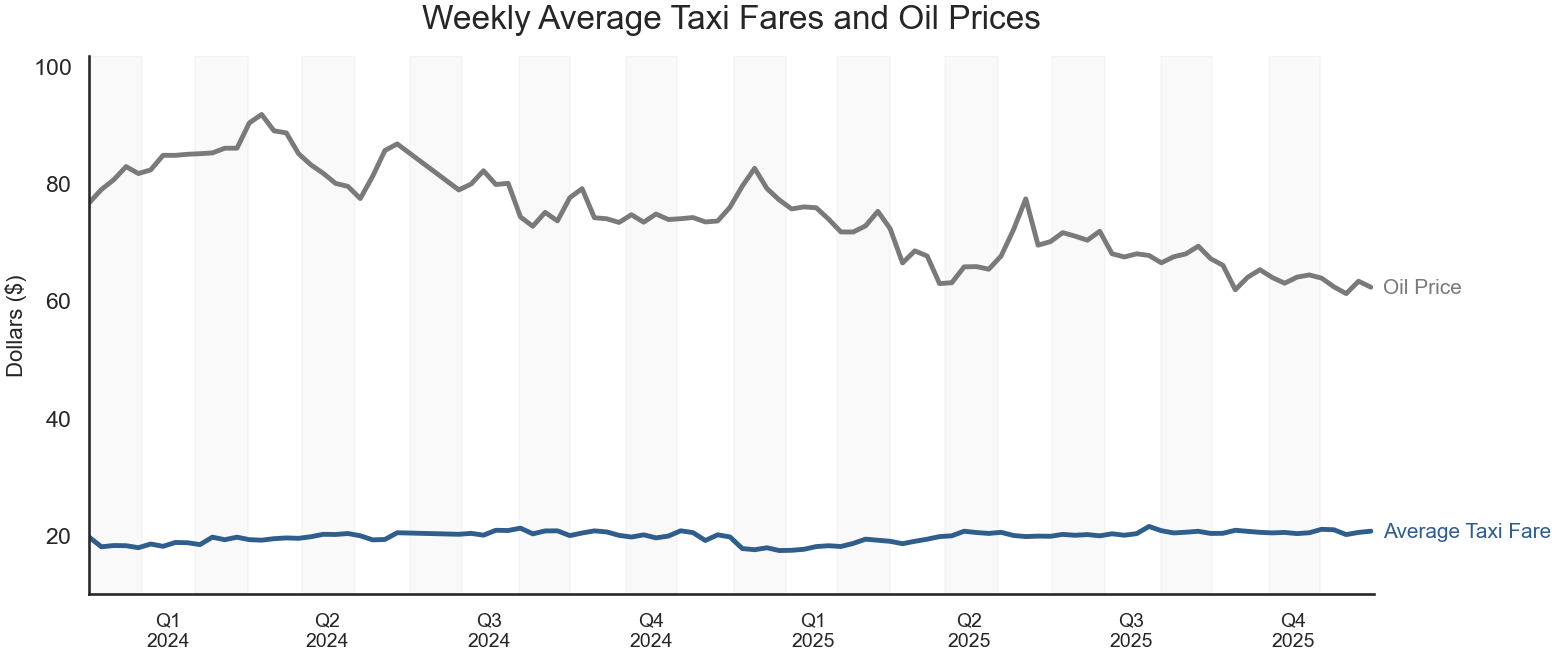

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# create week column
train_df["week_date"] = (
    train_df["tpep_pickup_datetime"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

# weekly averages
weekly_plot = train_df.groupby("week_date").agg(
    avg_fare=("fare_amount", "mean"),
    avg_oil_price=("oil_price", "mean")
).reset_index()

sns.set_theme(style="white", context="talk")

fig, ax = plt.subplots(figsize=(16, 7))

# alternating monthly shading
month_starts = pd.date_range(
    start="2024-01-01",
    end="2025-12-01",
    freq="MS"
)

for i, month_start in enumerate(month_starts):
    if i % 2 == 0:
        ax.axvspan(
            month_start,
            month_start + pd.offsets.MonthEnd(1),
            color="gray",
            alpha=0.045
        )

# plot lines
ax.plot(
    weekly_plot["week_date"],
    weekly_plot["avg_oil_price"],
    linewidth=3.5,
    color="#7A7A7A"
)

ax.plot(
    weekly_plot["week_date"],
    weekly_plot["avg_fare"],
    linewidth=3.5,
    color="#2F5D8C"
)

# direct labels
last_date = weekly_plot["week_date"].iloc[-1]

ax.text(
    last_date + pd.Timedelta(days=7),
    weekly_plot["avg_oil_price"].iloc[-1],
    "Oil Price",
    va="center",
    fontsize=15,
    color="#7A7A7A"
)

ax.text(
    last_date + pd.Timedelta(days=7),
    weekly_plot["avg_fare"].iloc[-1],
    "Average Taxi Fare",
    va="center",
    fontsize=15,
    color="#2F5D8C"
)

# centered quarter labels
quarter_ticks = [
    pd.Timestamp("2024-02-15"),
    pd.Timestamp("2024-05-15"),
    pd.Timestamp("2024-08-15"),
    pd.Timestamp("2024-11-15"),
    pd.Timestamp("2025-02-15"),
    pd.Timestamp("2025-05-15"),
    pd.Timestamp("2025-08-15"),
    pd.Timestamp("2025-11-15"),
]

quarter_labels = [
    "Q1\n2024", "Q2\n2024", "Q3\n2024", "Q4\n2024",
    "Q1\n2025", "Q2\n2025", "Q3\n2025", "Q4\n2025"
]

ax.set_xticks(quarter_ticks)
ax.set_xticklabels(quarter_labels, fontsize=14)

# titles and labels
ax.set_title(
    "Weekly Average Taxi Fares and Oil Prices",
    fontsize=24,
    pad=20
)

ax.set_ylabel("Dollars ($)", fontsize=16)
ax.set_xlabel("")

ax.set_xlim(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2025-12-31")
)

ax.set_ylim(
    10,
    weekly_plot["avg_oil_price"].max() + 10
)

# clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

## Trip Distance vs. Fare Amount

In [68]:
# Look at prices by pickup location
zone_lookup = pd.read_csv(data_path / "taxi_zone_lookup.csv")

zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
# Rename columns for merging
zone_lookup = zone_lookup.rename(columns={
    "LocationID": "PULocationID",
    "Borough": "pickup_borough",
    "Zone": "pickup_zone",
    "service_zone": "pickup_service_zone"
})

train_df = train_df.merge(
    zone_lookup,
    on="PULocationID",
    how="left"
)

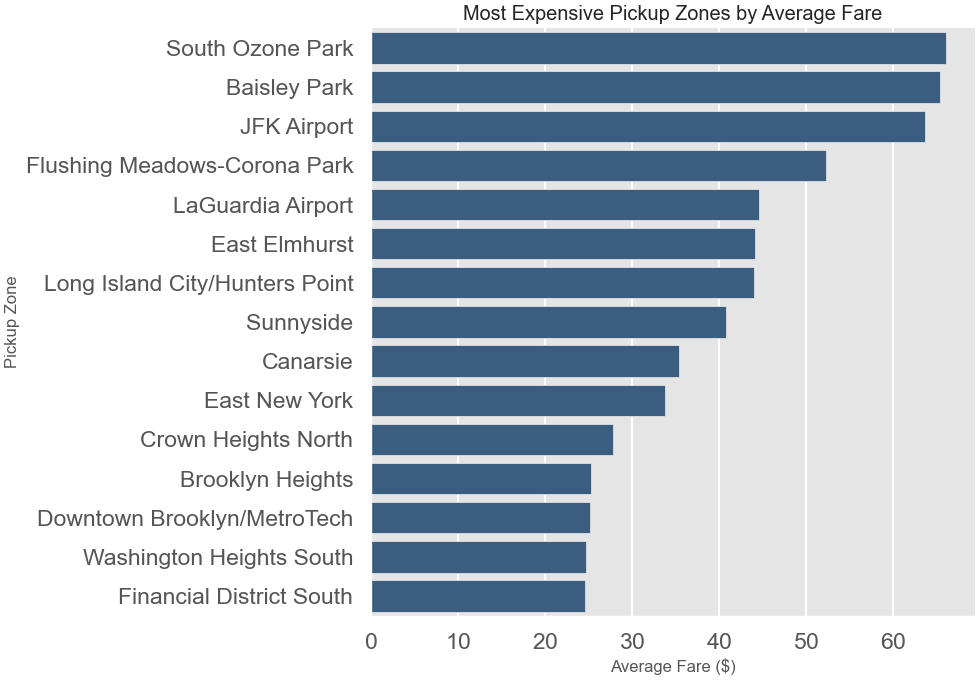

In [60]:
top_pickup_zones = (
    train_df
    .groupby("pickup_zone")
    .agg(
        avg_fare=("fare_amount", "mean"),
        trips=("fare_amount", "size")
    )
    .query("trips >= 1000")
    .sort_values("avg_fare", ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_pickup_zones,
    y="pickup_zone",
    x="avg_fare",
    color="#2F5D8C"
)

plt.title("Most Expensive Pickup Zones by Average Fare")
plt.xlabel("Average Fare ($)")
plt.ylabel("Pickup Zone")

sns.despine()
plt.tight_layout()
plt.show()

In [70]:
# load taxi zones shapefile
zones_gdf = gpd.read_file(
    data_path / "taxi_zones" / "taxi_zones.shp"
)

zones_gdf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [74]:
train_df["fare_per_mile"] = (
    train_df["fare_amount"] /
    train_df["trip_distance"]
)

# remove impossible values
train_df = train_df.replace(
    [np.inf, -np.inf],
    np.nan
)

train_df = train_df.dropna(
    subset=["fare_per_mile"]
)

In [76]:
map_df = train_df[
    (train_df["trip_distance"] >= 0.5) &
    (train_df["fare_amount"] > 0) &
    (train_df["fare_amount"] < 150) &
    (train_df["fare_per_mile"] < 25)
]

In [77]:
pickup_zone_stats = (
    map_df
    .groupby("PULocationID")
    .agg(
        avg_fare_per_mile=("fare_per_mile", "mean"),
        median_fare=("fare_amount", "median"),
        avg_distance=("trip_distance", "mean"),
        trips=("fare_amount", "size")
    )
    .reset_index()
)

In [78]:
zones_fares = zones_gdf.merge(
    pickup_zone_stats,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

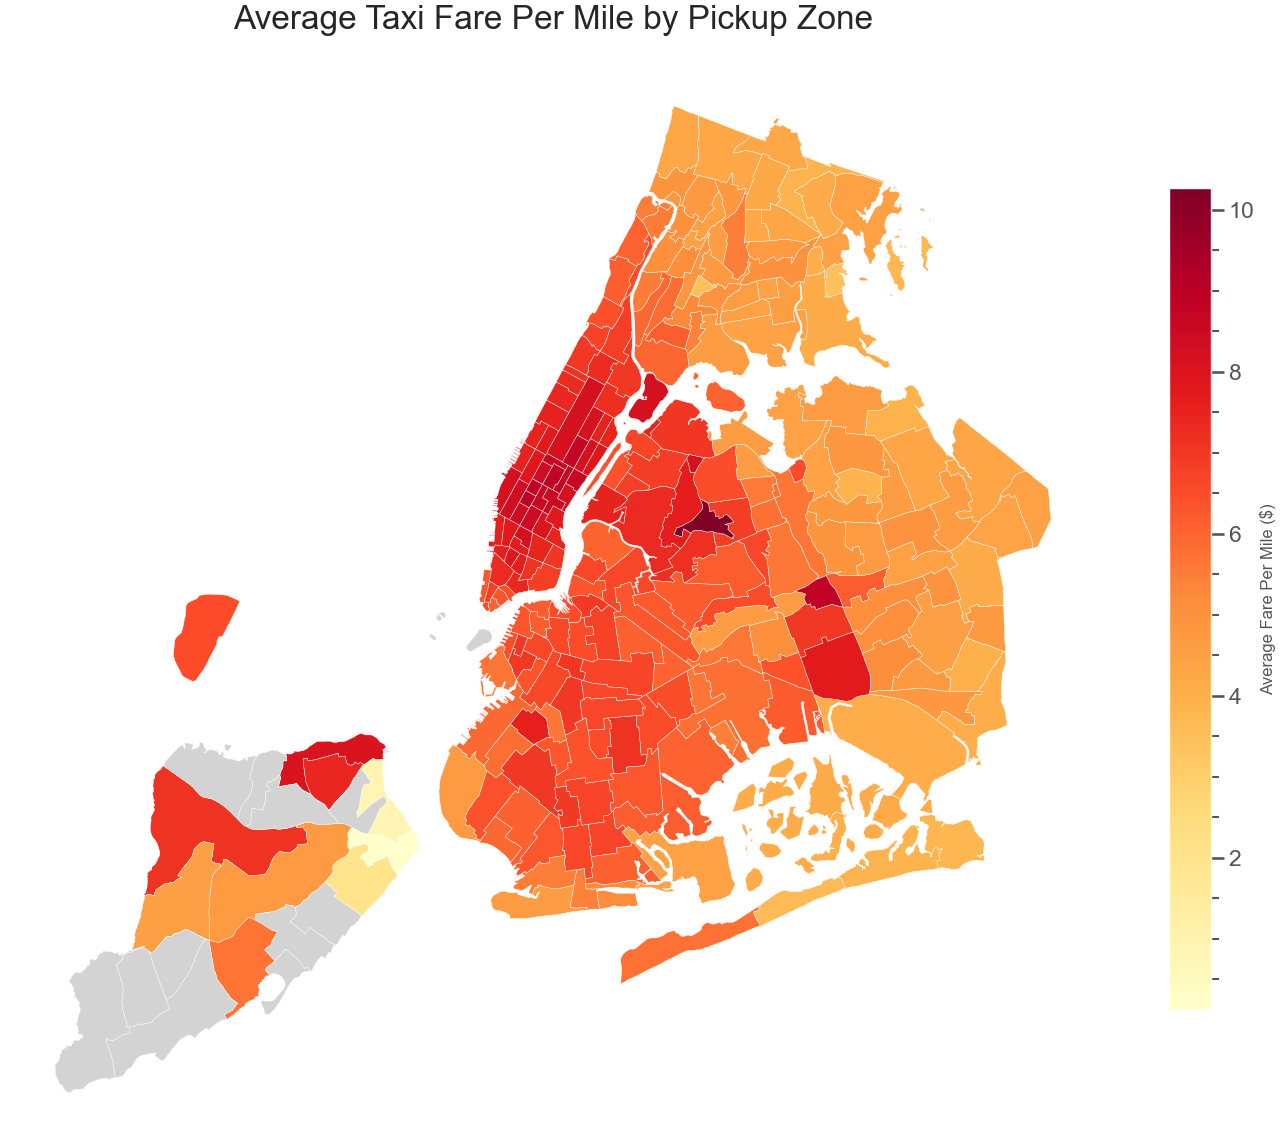

In [84]:
fig, ax = plt.subplots(figsize=(14, 14))

zones_fares.plot(
    column="avg_fare_per_mile",
    cmap="YlOrRd",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "Average Fare Per Mile ($)",
        "shrink": 0.6
    },
    ax=ax,
    missing_kwds={
        "color": "lightgrey"
    }
)

ax.set_title(
    "Average Taxi Fare Per Mile by Pickup Zone",
    fontsize=24,
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [85]:
expensive_zones = (
    zones_fares[
        ["zone", "borough", "avg_fare_per_mile", "trips"]
    ]
    .dropna()
    .sort_values(
        "avg_fare_per_mile",
        ascending=False
    )
)

expensive_zones.head(15)

,zone,borough,avg_fare_per_mile,trips
82,Elmhurst/Maspeth,Queens,10.267672,184.0
185,Penn Station/Madison Sq West,Manhattan,8.942196,105876.0
99,Garment District,Manhattan,8.886322,43586.0
133,Kew Gardens,Queens,8.869338,298.0
160,Midtown Center,Manhattan,8.866929,138629.0
236,Upper East Side South,Manhattan,8.741812,143443.0
161,Midtown East,Manhattan,8.659204,103972.0
162,Midtown North,Manhattan,8.607562,84590.0
228,Sutton Place/Turtle Bay North,Manhattan,8.598451,48849.0
163,Midtown South,Manhattan,8.566834,63351.0


In [86]:
zone_analysis = (
    zones_fares[
        [
            "zone",
            "borough",
            "avg_fare_per_mile",
            "avg_distance",
            "trips"
        ]
    ]
    .dropna()
)

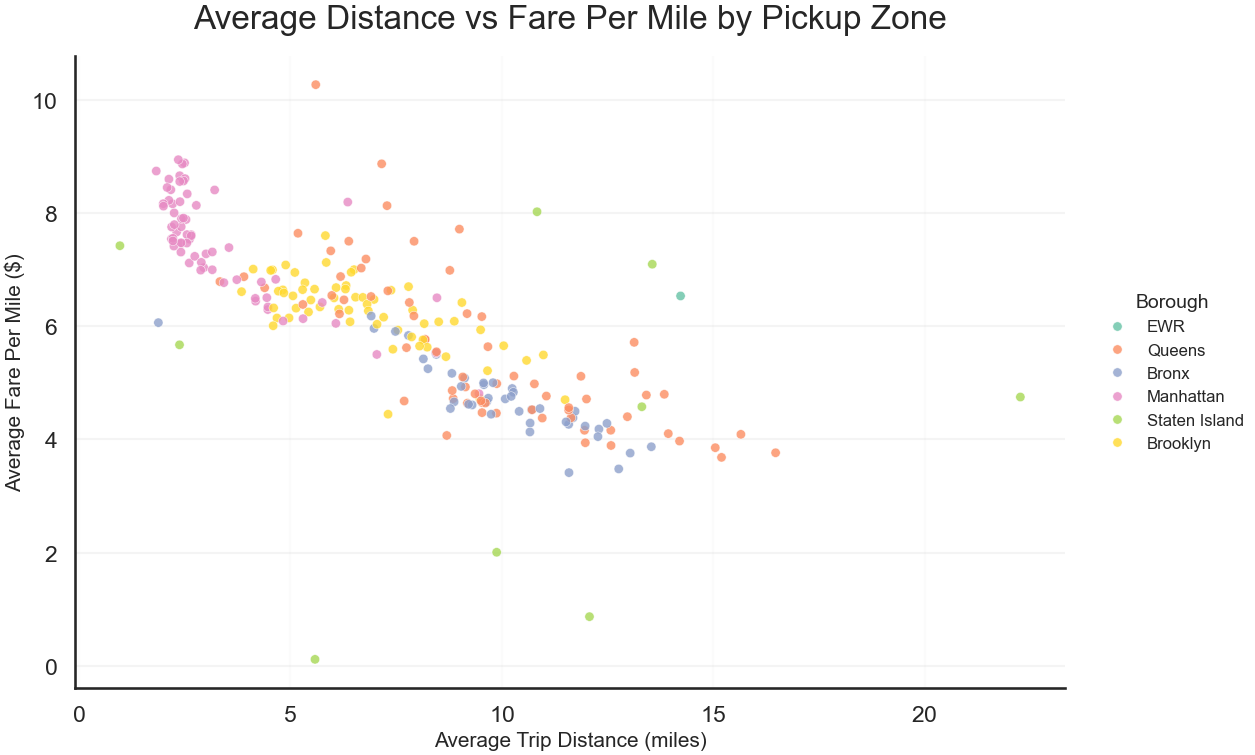

In [91]:
sns.set_theme(style="white", context="talk")

fig, ax = plt.subplots(figsize=(13, 8))

sns.scatterplot(
    data=zone_analysis,
    x="avg_distance",
    y="avg_fare_per_mile",
    hue="borough",
    s=45,                # fixed point size
    alpha=0.8,
    edgecolor="white",
    linewidth=0.4,
    palette="Set2",
    ax=ax
)

ax.legend(
    title="Borough",
    title_fontsize=14,
    fontsize=12,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

ax.set_title(
    "Average Distance vs Fare Per Mile by Pickup Zone",
    fontsize=24,
    pad=20
)

ax.set_xlabel(
    "Average Trip Distance (miles)",
    fontsize=15
)

ax.set_ylabel(
    "Average Fare Per Mile ($)",
    fontsize=15
)

# softer grid
ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", alpha=0.08)

# cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Residual analysis

In [92]:
from sklearn.linear_model import LinearRegression

X = train_df[["trip_distance"]]
y = train_df["fare_amount"]

model = LinearRegression()
model.fit(X, y)

train_df["predicted_fare"] = model.predict(X)

train_df["fare_residual"] = (
    train_df["fare_amount"] - train_df["predicted_fare"]
)

In [100]:
residual_zone = (
    train_df
    .groupby("PULocationID")
    .agg(
        median_residual=("fare_residual", "median"),
        trips=("fare_amount", "size")
    )
    .reset_index()
)

In [101]:
residual_map = zones_gdf.merge(
    residual_zone,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

In [102]:
residual_map["median_residual_clipped"] = (
    residual_map["median_residual"]
    .clip(-20, 20)
)

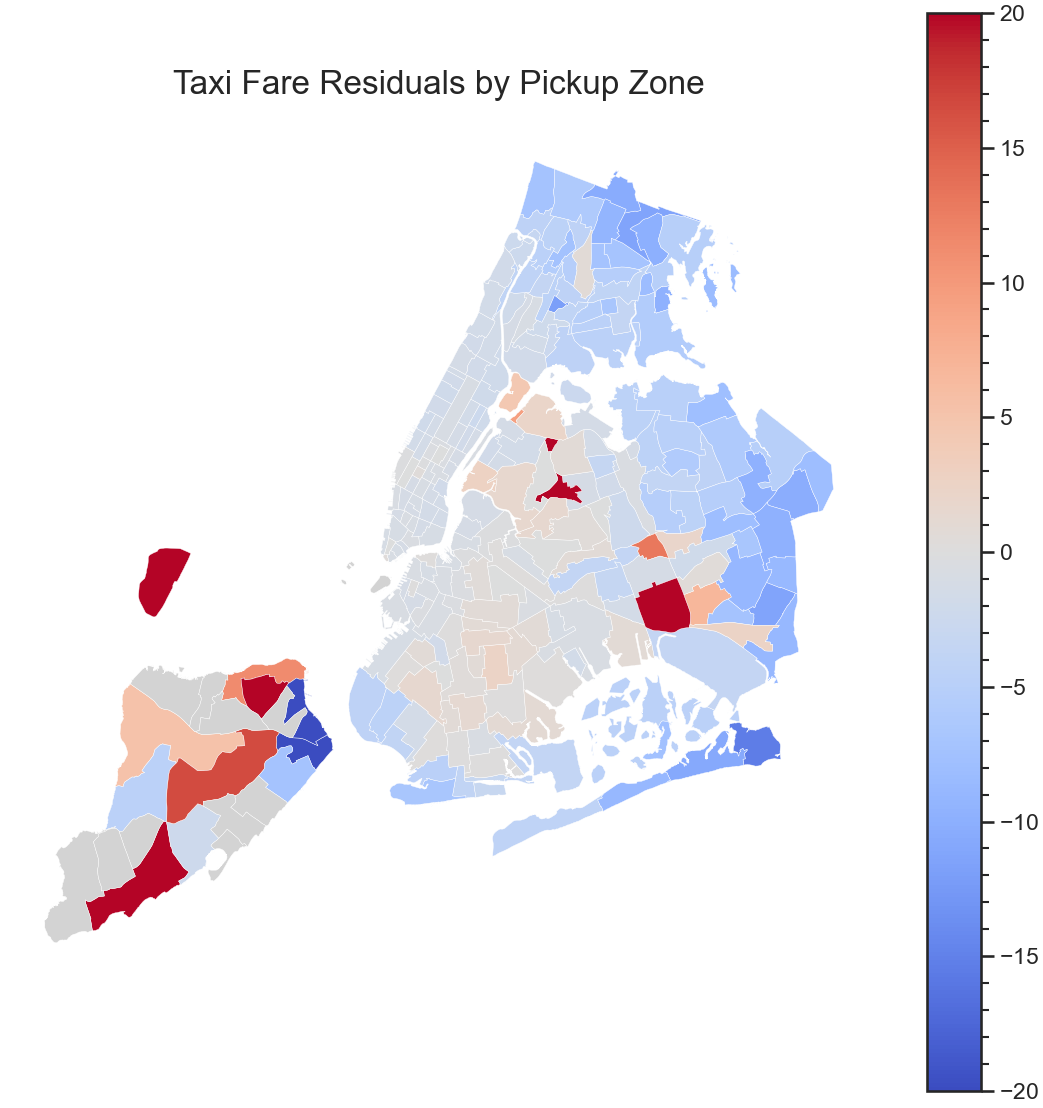

In [103]:
fig, ax = plt.subplots(figsize=(14, 14))

residual_map.plot(
    column="median_residual_clipped",
    cmap="coolwarm",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    vmin=-20,
    vmax=20
)

ax.set_title(
    "Taxi Fare Residuals by Pickup Zone",
    fontsize=24,
    pad=20
)

ax.axis("off")

plt.show()

## Rush Hour - More expensive?

In [105]:
train_df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_service_zone_x,pickup_borough_y,pickup_zone_y,pickup_service_zone_y,pickup_borough,pickup_zone,pickup_service_zone,fare_per_mile,predicted_fare,fare_residual
0,2,2024-04-07 13:26:07,2024-04-07 13:41:27,2.0,2.91,1.0,N,164,141,2,...,Yellow Zone,Manhattan,Midtown South,Yellow Zone,Manhattan,Midtown South,Yellow Zone,5.601375,17.807751,-1.507751
1,2,2025-01-24 20:39:17,2025-01-24 20:50:24,2.0,1.89,1.0,N,114,209,1,...,Yellow Zone,Manhattan,Greenwich Village South,Yellow Zone,Manhattan,Greenwich Village South,Yellow Zone,6.772487,13.996238,-1.196238
2,1,2025-10-24 12:15:20,2025-10-24 12:34:03,1.0,1.50,1.0,N,230,264,1,...,Yellow Zone,Manhattan,Times Sq/Theatre District,Yellow Zone,Manhattan,Times Sq/Theatre District,Yellow Zone,10.866667,12.538895,3.761105
3,2,2025-06-22 11:19:53,2025-06-22 11:23:35,3.0,1.79,5.0,N,129,138,1,...,Boro Zone,Queens,Jackson Heights,Boro Zone,Queens,Jackson Heights,Boro Zone,33.441341,13.622560,46.237440
4,2,2024-04-23 11:37:09,2024-04-23 11:56:47,1.0,1.57,1.0,N,161,140,1,...,Yellow Zone,Manhattan,Midtown Center,Yellow Zone,Manhattan,Midtown Center,Yellow Zone,11.273885,12.800469,4.899531


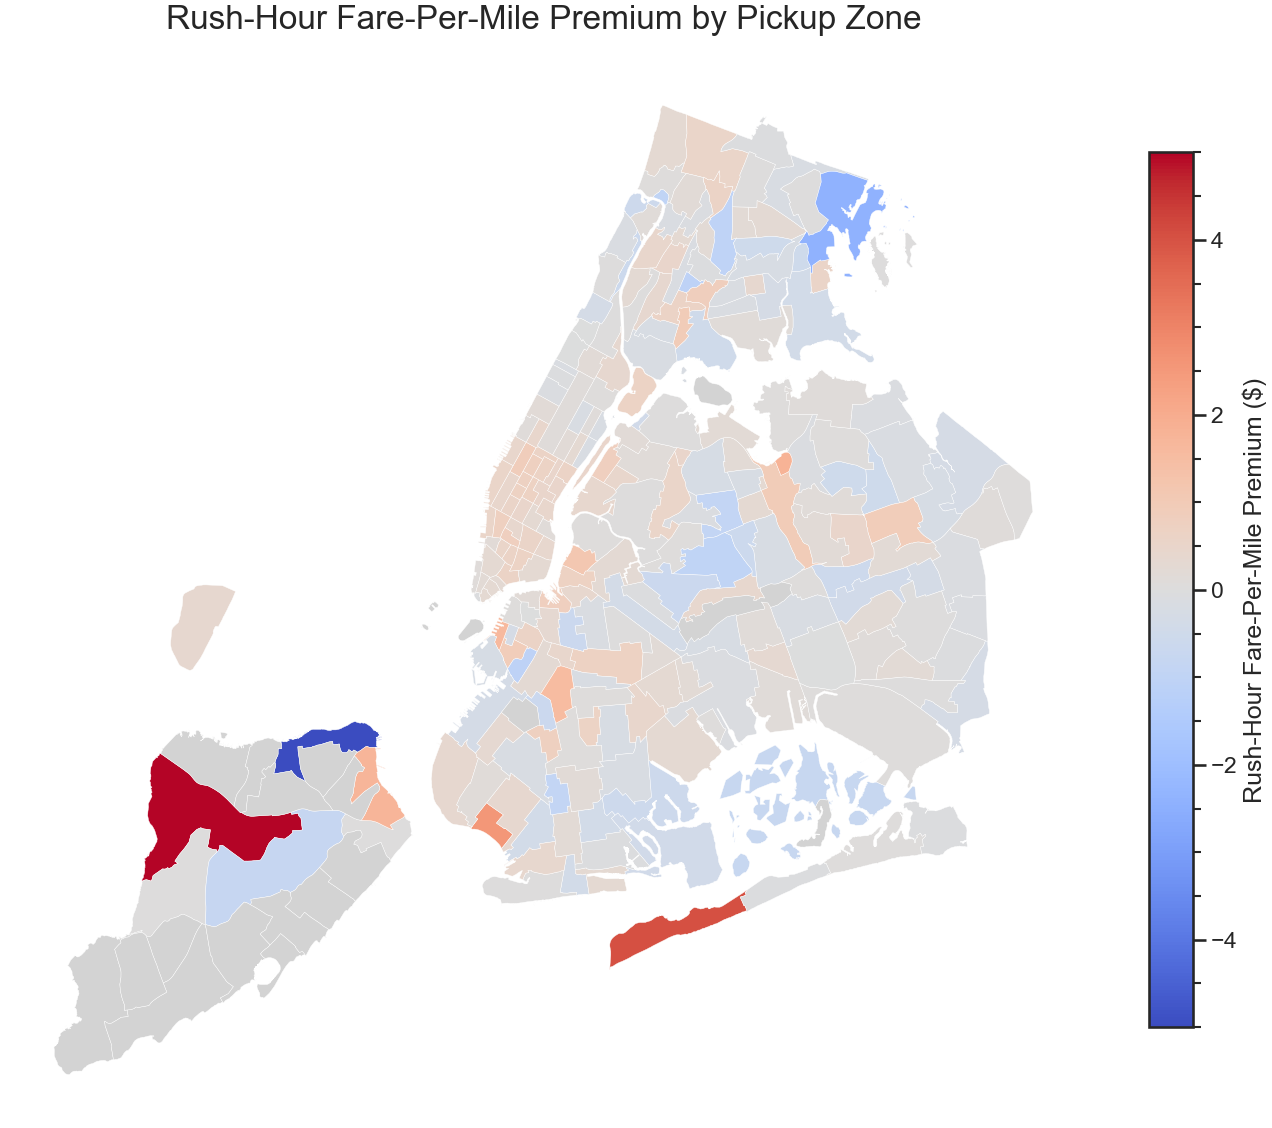

In [111]:
# -----------------------------------------
# Rush-hour fare-per-mile premium by zone
# -----------------------------------------

# create pickup hour
train_df["pickup_hour"] = train_df["tpep_pickup_datetime"].dt.hour

# define rush hour
train_df["rush_hour"] = train_df["pickup_hour"].isin([7, 8, 9, 16, 17, 18])

# make sure fare_per_mile exists
train_df["fare_per_mile"] = train_df["fare_amount"] / train_df["trip_distance"]

# filter to stable observations
rush_df = train_df[
    (train_df["trip_distance"] >= 0.5) &
    (train_df["fare_amount"] > 0) &
    (train_df["fare_amount"] < 150) &
    (train_df["fare_per_mile"] < 25)
].copy()

# median fare per mile by zone and rush-hour status
rush_stats = (
    rush_df
    .groupby(["PULocationID", "rush_hour"])
    .agg(
        median_fare_per_mile=("fare_per_mile", "median"),
        trips=("fare_per_mile", "size")
    )
    .reset_index()
)

# pivot rush/non-rush into columns
rush_pivot = rush_stats.pivot(
    index="PULocationID",
    columns="rush_hour",
    values="median_fare_per_mile"
).reset_index()

rush_pivot.columns = [
    "PULocationID",
    "non_rush_fpm",
    "rush_fpm"
]

# compute rush-hour premium
rush_pivot["rush_hour_premium"] = (
    rush_pivot["rush_fpm"] - rush_pivot["non_rush_fpm"]
)

# merge onto map
rush_map = zones_gdf.merge(
    rush_pivot,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

# clip extreme values for readable map
rush_map["rush_hour_premium_clipped"] = rush_map["rush_hour_premium"].clip(-5, 5)

# plot
fig, ax = plt.subplots(figsize=(14, 14))

rush_map.plot(
    column="rush_hour_premium_clipped",
    cmap="coolwarm",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    vmin=-5,
    vmax=5,
    legend_kwds={
        "label": "Rush-Hour Fare-Per-Mile Premium ($)",
        "shrink": 0.65
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "Rush-Hour Fare-Per-Mile Premium by Pickup Zone",
    fontsize=24,
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.show()

# Correlation & Feature Relationships

2.1 Correlation heatmap

Core numeric variables.

2.2 Target-focused correlations

Specifically:

what affects fare_amount
what affects fare_per_mile
2.3 Pairplots / focused scatterplots

Only for the most important relationships.

2.4 Interpret findings

In [114]:
corr_cols = [
    "fare_amount",
    "trip_distance",
    "fare_per_mile",
    "tip_amount",
    "tolls_amount",
    "congestion_surcharge",
    "Airport_fee",
    "passenger_count",
    "total_amount"
]

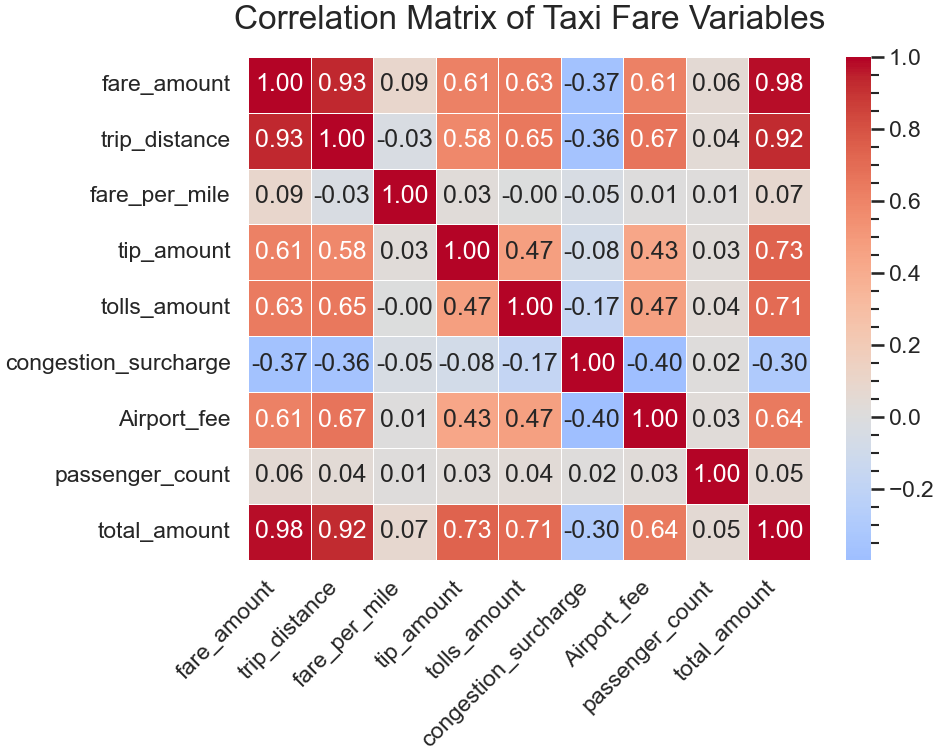

In [115]:
# Correlation matrix
corr_matrix = train_df[corr_cols].corr()

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Taxi Fare Variables",
    fontsize=24,
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

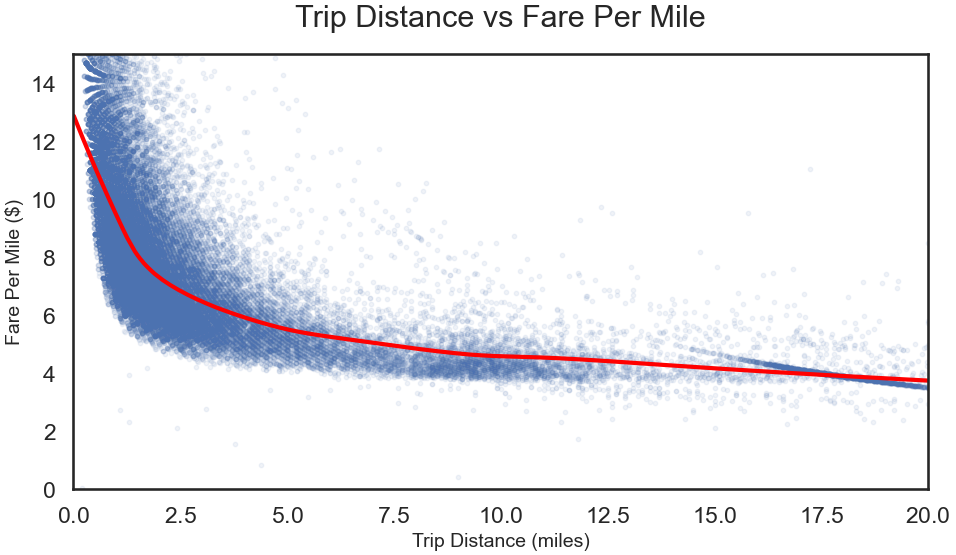

In [119]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=train_df.sample(50000, random_state=42),
    x="trip_distance",
    y="fare_per_mile",
    lowess=True,
    scatter_kws={
        "alpha": 0.08,
        "s": 10,
        "color": "#4C72B0"
    },
    line_kws={
        "color": "red",
        "linewidth": 3
    }
)

plt.title(
    "Trip Distance vs Fare Per Mile",
    fontsize=22,
    pad=20
)

plt.xlabel("Trip Distance (miles)", fontsize=14)
plt.ylabel("Fare Per Mile ($)", fontsize=14)

# Better visual limits
plt.xlim(0, 20)
plt.ylim(0, 15)

plt.tight_layout()
plt.show()